# Finite Difference Methods for Hyperbolic PDEs

**Question.** Consider the one-way wave equation

$$
\begin{cases}
u_t + u_x = 0, & x>-2,\ t>0, \\
u(-2,t)=0, & t\ge 0, \\
u(x,0)=u_0(x)=
\begin{cases}
(1-|x|)^2, & |x|\le 1, \\
0, & |x|>1.
\end{cases}
\end{cases}
$$

We test the schemes `FTFS`, `FTBS`, `FTCS`, `CTCS (Leapfrog)`, `Lax-Friedrichs`, `Lax-Wendroff`, `Beam-Warming`, `BTFS`, `BTBS`, `BTCS`, and `Crank-Nicolson`, then study their accuracy, convergence, and stability numerically on $x \in [-2,3]$ for representative values such as $h=0.1, 0.05, 0.01$ and $\lambda = k/h = 0.8, 0.9$.


## Notebook goal

This notebook is a cell-by-cell conversion of `scripts/problem3_hyperbolic_fd.py`. It keeps the same numerical setup, but reorganizes the code so each part of the experiment can be run and inspected interactively.

For the advection equation with speed $a=1$, the exact solution is the translated initial profile

$$
u(x,t)=u_0(x-t) \quad \text{whenever } x-t>-2,
$$

with the left boundary condition enforcing zero outside the inflow domain.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True


## Problem setup

We define the initial condition, the exact solution, and a helper for building the grid from the mesh width $h$ and Courant number $\lambda = k/h$.


In [2]:
a = 1.0
x0 = -2.0
b = 3.0


def u0(x):
    return np.where(np.abs(x) <= 1.0, (1.0 - np.abs(x)) ** 2, 0.0)


def u_exact(x, t):
    xt = x - t
    return np.where(xt > x0, u0(xt), 0.0)


def make_grid(h, lam):
    k = lam * h
    x = np.arange(x0, b + h / 2, h)
    return x, k


## Explicit one-step schemes

The function below advances one time step for the explicit methods. The implementation matches the original script, including the simple one-sided treatment at the right boundary.


In [3]:
def advance_explicit(u, lam, scheme, u_left=0.0):
    """Advance one time step for the explicit schemes."""
    N = len(u)
    v = np.zeros_like(u)
    v[0] = u_left

    if scheme == "FTFS":
        for m in range(1, N - 1):
            v[m] = u[m] - lam * (u[m + 1] - u[m])
        v[-1] = u[-1] - lam * (u[-1] - u[-2])
    elif scheme == "FTBS":
        for m in range(1, N):
            v[m] = u[m] - lam * (u[m] - u[m - 1])
    elif scheme == "FTCS":
        for m in range(1, N - 1):
            v[m] = u[m] - 0.5 * lam * (u[m + 1] - u[m - 1])
        v[-1] = u[-1] - lam * (u[-1] - u[-2])
    elif scheme == "LaxFriedrichs":
        for m in range(1, N - 1):
            v[m] = 0.5 * (u[m + 1] + u[m - 1]) - 0.5 * lam * (u[m + 1] - u[m - 1])
        v[-1] = u[-1] - lam * (u[-1] - u[-2])
    elif scheme == "LaxWendroff":
        for m in range(1, N - 1):
            v[m] = (
                u[m]
                - 0.5 * lam * (u[m + 1] - u[m - 1])
                + 0.5 * lam ** 2 * (u[m + 1] - 2 * u[m] + u[m - 1])
            )
        v[-1] = u[-1] - lam * (u[-1] - u[-2])
    elif scheme == "BeamWarming":
        v[1] = u[1] - lam * (u[1] - u[0])
        for m in range(2, N):
            v[m] = (
                u[m]
                - 0.5 * lam * (3 * u[m] - 4 * u[m - 1] + u[m - 2])
                + 0.5 * lam ** 2 * (u[m] - 2 * u[m - 1] + u[m - 2])
            )
    else:
        raise ValueError(f"Unknown scheme: {scheme}")

    return v


def run_explicit(h, lam, T, scheme):
    x, k = make_grid(h, lam)
    u = u0(x)
    u[0] = 0.0
    nsteps = int(round(T / k))

    for _ in range(nsteps):
        u = advance_explicit(u, lam, scheme)

    return x, u


## Leapfrog and implicit schemes

For `CTCS`, we first generate level `n=1` with `FTBS`. For the implicit methods, we solve a tridiagonal system at every time step using `scipy.linalg.solve_banded`.


In [4]:
def run_ctcs(h, lam, T):
    x, k = make_grid(h, lam)
    N = len(x)
    u_old = u0(x)
    u_old[0] = 0.0
    u_cur = advance_explicit(u_old, lam, "FTBS")
    nsteps = int(round(T / k))

    for _ in range(1, nsteps):
        v = np.zeros(N)
        v[0] = 0.0
        for m in range(1, N - 1):
            v[m] = u_old[m] - lam * (u_cur[m + 1] - u_cur[m - 1])
        v[-1] = u_cur[-1] - lam * (u_cur[-1] - u_cur[-2])
        u_old = u_cur
        u_cur = v

    return x, u_cur


def run_implicit(h, lam, T, scheme):
    x, k = make_grid(h, lam)
    N = len(x)
    u = u0(x)
    u[0] = 0.0
    nsteps = int(round(T / k))

    for _ in range(nsteps):
        rhs = u.copy()
        M = N - 1
        sub = np.zeros(M)
        main = np.ones(M)
        sup = np.zeros(M)
        rhs_int = rhs[1:].copy()

        if scheme == "BTBS":
            main[:] = 1 + lam
            sub[1:] = -lam
        elif scheme == "BTFS":
            main[:] = 1 - lam
            sup[:-1] = lam
        elif scheme == "BTCS":
            main[:] = 1.0
            sup[:-1] = lam / 2.0
            sub[1:] = -lam / 2.0
        elif scheme == "CrankNicolson":
            main[:] = 1.0
            sup[:-1] = lam / 4.0
            sub[1:] = -lam / 4.0
            rhs_int[:-1] -= lam / 4.0 * (u[2:N] - u[0:N-2])
            rhs_int[-1] -= lam / 4.0 * (u[N - 1] - u[N - 3])
        else:
            raise ValueError(f"Unknown scheme: {scheme}")

        ab = np.zeros((3, M))
        ab[0, 1:] = sup[:-1]
        ab[1, :] = main
        ab[2, :-1] = sub[1:]

        sol = solve_banded((1, 1), ab, rhs_int)
        u[1:] = sol
        u[0] = 0.0

    return x, u


## Compare all schemes at one final time

This reproduces the main comparison figure from the script for $T=1.5$, $h=0.05$, and $\lambda=0.8$.


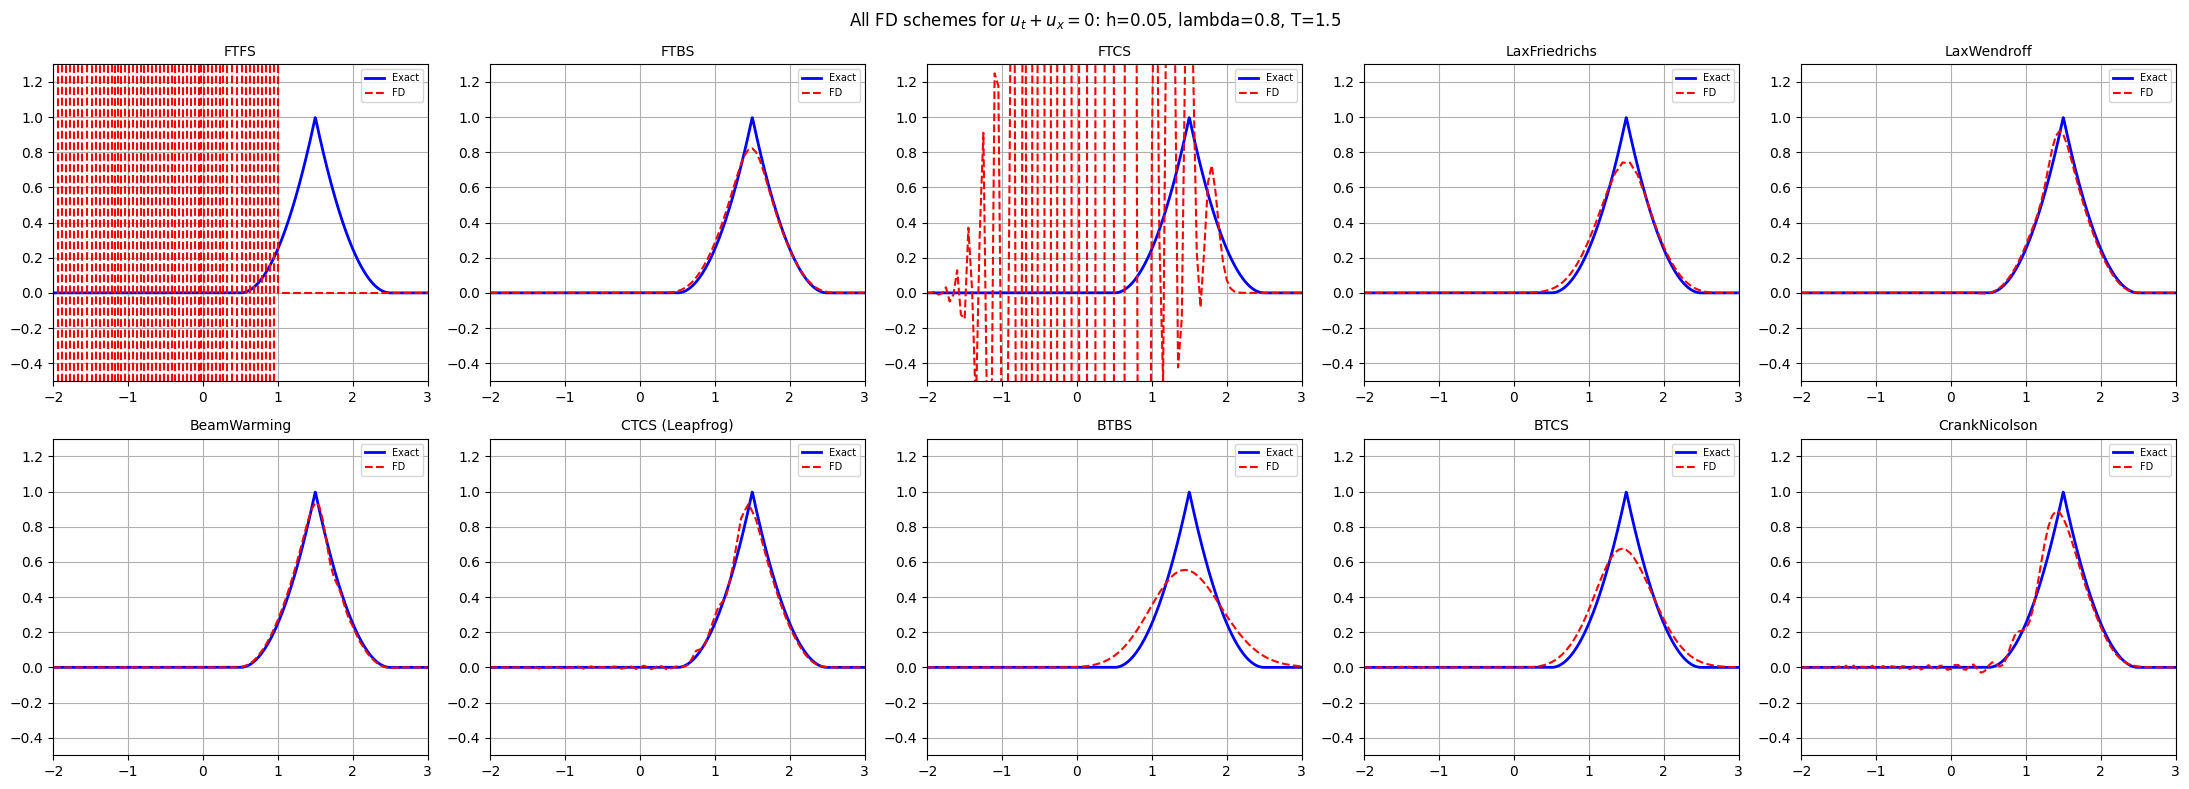

In [5]:
T = 1.5
h = 0.05
lam = 0.8

x_fine = np.linspace(x0, b, 1000)
u_ex = u_exact(x_fine, T)

explicit_schemes = ["FTFS", "FTBS", "FTCS", "LaxFriedrichs", "LaxWendroff", "BeamWarming"]
implicit_schemes = ["BTBS", "BTCS", "CrankNicolson"]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

panel = 0
for scheme in explicit_schemes:
    xn, un = run_explicit(h, lam, T, scheme)
    axes[panel].plot(x_fine, u_ex, "b-", lw=2, label="Exact")
    axes[panel].plot(xn, un, "r--", lw=1.5, label="FD")
    axes[panel].set_title(scheme, fontsize=10)
    axes[panel].set_xlim(-2, b)
    axes[panel].set_ylim(-0.5, 1.3)
    axes[panel].legend(fontsize=7)
    panel += 1

xn, un = run_ctcs(h, lam, T)
axes[panel].plot(x_fine, u_ex, "b-", lw=2, label="Exact")
axes[panel].plot(xn, un, "r--", lw=1.5, label="FD")
axes[panel].set_title("CTCS (Leapfrog)", fontsize=10)
axes[panel].set_xlim(-2, b)
axes[panel].set_ylim(-0.5, 1.3)
axes[panel].legend(fontsize=7)
panel += 1

for scheme in implicit_schemes:
    xn, un = run_implicit(h, lam, T, scheme)
    axes[panel].plot(x_fine, u_ex, "b-", lw=2, label="Exact")
    axes[panel].plot(xn, un, "r--", lw=1.5, label="FD")
    axes[panel].set_title(scheme, fontsize=10)
    axes[panel].set_xlim(-2, b)
    axes[panel].set_ylim(-0.5, 1.3)
    axes[panel].legend(fontsize=7)
    panel += 1

for j in range(panel, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"All FD schemes for $u_t+u_x=0$: h={h}, lambda={lam}, T={T}", fontsize=12)
fig.tight_layout()
plt.show()


## Convergence study

The original script measures the maximum error for `FTBS`, `Lax-Wendroff`, and `CTCS` on a sequence of refined meshes. The observed rates help us compare the numerical results with the expected order of each scheme.



Convergence: FTBS
  h=0.5000  err=2.800e-01
  h=0.4737  err=2.728e-01
  h=0.4475  err=2.005e-01
  h=0.4212  err=3.311e-01
  h=0.3949  err=1.043e-01
  h=0.3687  err=2.820e-01
  h=0.3424  err=2.117e-01
  h=0.3162  err=1.462e-01
  h=0.2899  err=1.231e-01
  h=0.2636  err=2.227e-01
  h=0.2374  err=1.772e-01
  h=0.2111  err=2.348e-01
  h=0.1848  err=2.219e-01
  h=0.1586  err=2.400e-01
  h=0.1323  err=1.608e-01
  h=0.1061  err=1.678e-01
  h=0.0798  err=1.213e-01
  h=0.0535  err=1.503e-01
  h=0.0273  err=1.116e-01
  h=0.0010  err=2.236e-02
  Rates: [ 0.037  0.444 -0.723  1.667 -1.435  0.414  0.534  0.249 -0.855  0.329
 -0.406  0.081 -0.113  0.578 -0.061  0.467 -0.309  0.43   2.319]

Convergence: LaxWendroff
  h=0.5000  err=4.016e-01
  h=0.4737  err=1.350e-01
  h=0.4475  err=1.789e-01
  h=0.4212  err=2.426e-01
  h=0.3949  err=1.802e-01
  h=0.3687  err=2.613e-01
  h=0.3424  err=1.263e-01
  h=0.3162  err=1.089e-01
  h=0.2899  err=2.157e-01
  h=0.2636  err=9.974e-02
  h=0.2374  err=1.687e-01
  h=

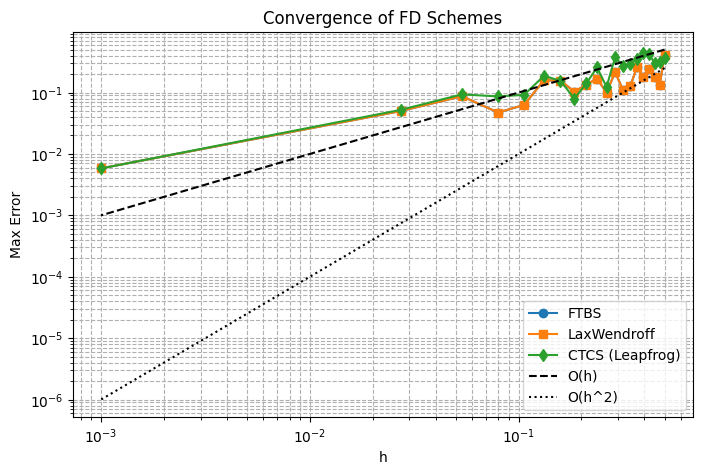

In [10]:
def max_error(x, u_num, T):
    return np.max(np.abs(u_num - u_exact(x, T)))


def print_convergence_report(label, hs, errs):
    print(f"\nConvergence: {label}")
    for h_val, err in zip(hs, errs):
        print(f"  h={h_val:.4f}  err={err:.3e}")
    if len(errs) > 1:
        rates = np.log2(np.array(errs[:-1]) / np.array(errs[1:]))
        print("  Rates:", np.round(rates, 3))


T_conv = 1.0
lam_conv = 0.8
# hs = [0.1, 0.05, 0.025, 0.0125]
hs = np.linspace(0.5, 0.001, 20)

for scheme in ["FTBS", "LaxWendroff"]:
    errs = []
    for h_val in hs:
        x_num, u_num = run_explicit(h_val, lam_conv, T_conv, scheme)
        errs.append(max_error(x_num, u_num, T_conv))
    print_convergence_report(scheme, hs, errs)

errs_ctcs = []
for h_val in hs:
    x_num, u_num = run_ctcs(h_val, lam_conv, T_conv)
    errs_ctcs.append(max_error(x_num, u_num, T_conv))
print_convergence_report("CTCS (Leapfrog)", hs, errs_ctcs)

# Plot convergence for FTBS, LaxWendroff, and CTCS
plt.figure(figsize=(8, 5))
plt.loglog(hs, errs, "o-", label="FTBS")
plt.loglog(hs, errs, "s-", label="LaxWendroff")
plt.loglog(hs, errs_ctcs, "d-", label="CTCS (Leapfrog)")
plt.xlabel("h")
plt.ylabel("Max Error")
plt.title("Convergence of FD Schemes")
# Plot reference lines for first and second order convergence
h_ref = np.array(hs)
plt.loglog(h_ref, h_ref, "k--", label="O(h)")
plt.loglog(h_ref, h_ref**2, "k:", label="O(h^2)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


## Stability comparison

Here we compare a stable upwind scheme (`FTBS`, for $a>0$ and $\lambda \le 1$) with $FTCS$, which is well known to be unstable for the advection equation.


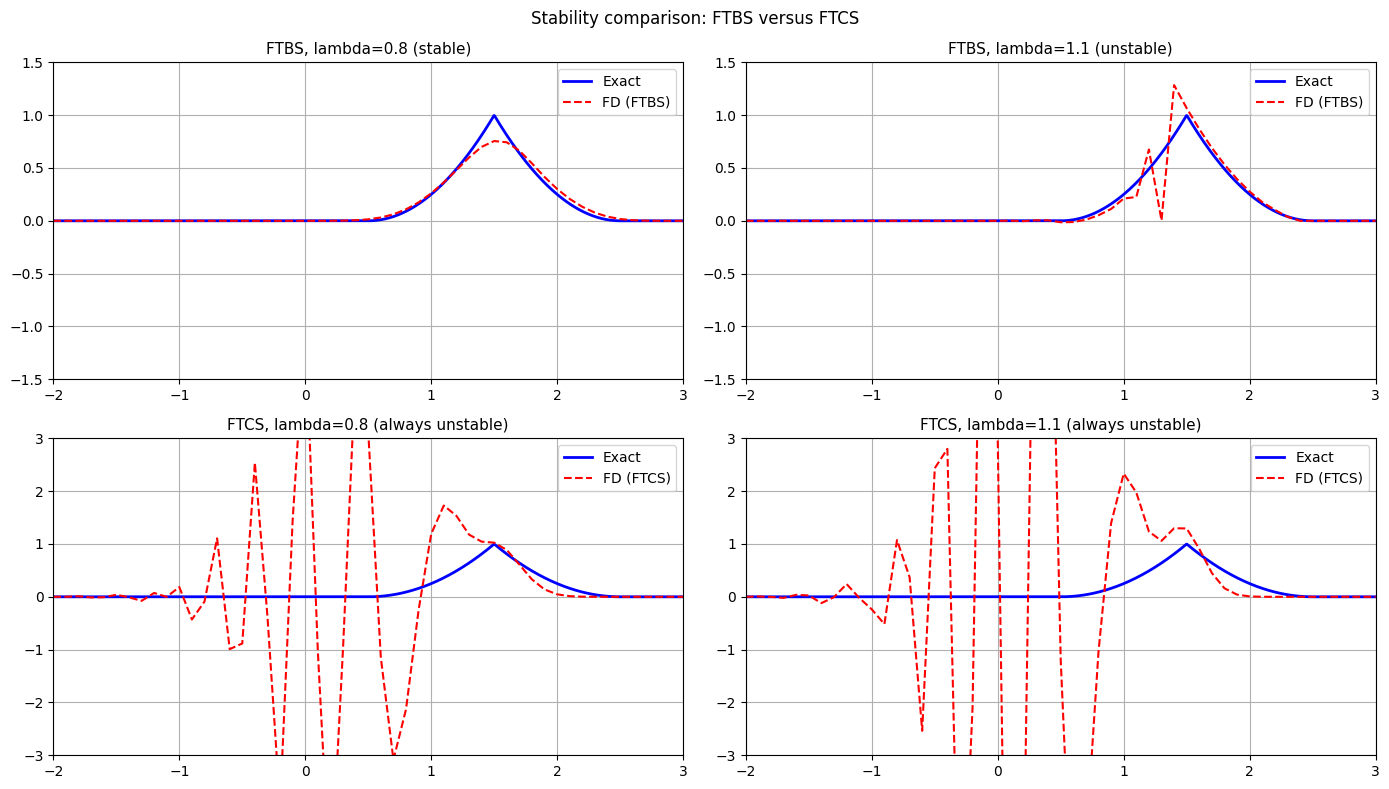

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, lam_test in enumerate([0.8, 1.1]):
    x_num, u_num = run_explicit(0.1, lam_test, T, "FTBS")
    axes[0, col].plot(x_fine, u_exact(x_fine, T), "b-", lw=2, label="Exact")
    axes[0, col].plot(x_num, u_num, "r--", lw=1.5, label="FD (FTBS)")
    axes[0, col].set_title(
        f"FTBS, lambda={lam_test} ({'stable' if lam_test <= 1 else 'unstable'})",
        fontsize=11,
    )
    axes[0, col].set_xlim(-2, b)
    lim = 1.5 if lam_test <= 1 else max(1.5, np.max(np.abs(u_num)) * 1.1)
    axes[0, col].set_ylim(-lim, lim)
    axes[0, col].legend()

    x_num, u_num = run_explicit(0.1, lam_test, T, "FTCS")
    axes[1, col].plot(x_fine, u_exact(x_fine, T), "b-", lw=2, label="Exact")
    axes[1, col].plot(x_num, u_num, "r--", lw=1.5, label="FD (FTCS)")
    axes[1, col].set_title(f"FTCS, lambda={lam_test} (always unstable)", fontsize=11)
    axes[1, col].set_xlim(-2, b)
    lim2 = 1.5 if np.max(np.abs(u_num)) < 2 else 3.0
    axes[1, col].set_ylim(-lim2, lim2)
    axes[1, col].legend()

fig.suptitle("Stability comparison: FTBS versus FTCS", fontsize=12)
fig.tight_layout()
plt.show()


## What to look for in the results

- `FTFS` should behave poorly for right-moving advection because it uses the wrong spatial bias.
- `FTBS` is the natural upwind scheme for `a>0`; it is stable when `0 <= lambda <= 1`, but it is diffusive.
- `FTCS` is unstable for this hyperbolic problem, even when `lambda < 1`.
- `Lax-Friedrichs` is usually more stable than `FTCS`, but its artificial dissipation smooths the profile.
- `Lax-Wendroff`, `Beam-Warming`, and `CTCS` are higher-order methods and often give sharper profiles, though they may show oscillations near steep gradients.
- Among the implicit methods, `BTBS` is typically the most reasonable upwind-style choice for `a>0`, while centered implicit methods can be less dissipative but may show phase errors.
